In [1]:
#CODIGO COMPLETO

# Project: Y4GA.Financial Co-pilot AI-powered 
# FIRST CODE
# OBJETIVE: Create my DataSet about my Uber_Rides
# TOOLS: PDFPLUMBER, REGEX (Regular Expressions)

import pdfplumber
import re

file_pdf = "resumen_16 de dic%2C 4_00.pdf"   #  <--------------- definimos nuestro archivo (nombre/ruta)
complete_text = ""      # <---------------- Solo hay que crearlo para despues almacenar

with pdfplumber.open(file_pdf) as pdf:
    for page in pdf.pages:
        text= page.extract_text()
        if text: 
            complete_text += text + "\n"
    
    total_pages = len(pdf.pages) # <--------- Conteo páginas

initial_text = complete_text # <------------El texto o caracteres en crudo

print(f"¡Éxito! Se leyeron {total_pages} páginas!")

with pdfplumber.open(file_pdf) as pdf:
    text_page1 = pdf.pages[0].extract_text()#<------SOLO la página 1 para análisis nombre/fecha
    

name_pattern = r"\n([^\n]+)\n\+\d+" # <--------- Regex nombre
match_name = re.search(name_pattern, text_page1)
driver_name = match_name.group(1).strip() if match_name else "No encontrado"


date_pattern = r"(\d{2}/\d{2}/\d{4}).*?(\d{2}/\d{2}/\d{4})" # ------ Regex para extraer fecha 
match_date = re.search(date_pattern, text_page1)
if match_date:
    date_ini = match_date.group(1)
    date_fin = match_date.group(2)
    weekly_period = f"Del {date_ini} al {date_fin}" 
else:
    weekly_period = "No encontrada"
    print("-" * 45)



trips_pattern = r"Cantidad total de viajes completados[^\d]*(\d+)"   #<--------- Regex Viajes 
match_trips = re.search(trips_pattern, initial_text)
total_trips = int(match_trips.group(1)) if match_trips else 0


time_pattern = r"Tiempo efectivo trabajado.*?(\d+)\s*h\s*(\d+)\s*m"   #<---------Regex para Tiempo Conectado
match_time = re.search(time_pattern, initial_text, re.DOTALL)
if match_time:
    hours = int(match_time.group(1))
    minutes = int(match_time.group(2))
    total_hours_decimal = round(hours + (minutes / 60.0), 2)  #<----Convertimos a decimal para futuros cálculos
    formatted_time = f"{hours}h {minutes}m"
else:
    formatted_time = "Not found"




gross_pattern = r"Monto bruto generado[^\d]*([\d,]+\.\d{2})"  #<--------------- Regex para Monto Bruto Generado
match_gross = re.search(gross_pattern, text_page1)

if match_gross:
    gross_str = match_gross.group(1)
    gross_float = float(gross_str.replace(",", ""))   #FORMATO FLOAT-INT
    formatted_gross_amount = f"${gross_float:,.2f}"
else:
    formatted_gross_amount = "Not found"



tips_pattern = r"Propinas otorgadas por usuarios[^\d\$]*\$([\d,\.]+)"   #<------ Regex Propinas
match_tips = re.search(tips_pattern, initial_text, re.IGNORECASE)

if match_tips:
    tips_str = match_tips.group(1).replace(",", "")
    tips_amount = float(tips_str)
    formatted_tips = f"${tips_amount:,.2f}"
else:
    tips_amount = 0.0
    formatted_tips = "$0.00"


incentives_pattern = r"Comisión por promoción y fomento[^\d\$]*\$([\d,\.]+)"   #<----------- Regex para Incentivos
match_incentives = re.search(incentives_pattern, initial_text, re.IGNORECASE) 

if match_incentives:
    incentives_str = match_incentives.group(1).replace(",", "")
    incentives_amount = float(incentives_str)
    formatted_incentives = f"${incentives_amount:,.2f}"
else:
    incentives_amount = 0.0
    formatted_incentives = "$0.00"



taxes_pattern = r"Impuestos[^\d\-]*-\$([\d,\.]+)"                   #<----------- Regex Impuestos
match_taxes = re.search(taxes_pattern, initial_text, re.IGNORECASE)

if match_taxes:
    taxes_str = match_taxes.group(1).replace(",", "")
    taxes_amount = -float(taxes_str)
    formatted_taxes = f"-${abs(taxes_amount):,.2f}"
else:
    taxes_amount = 0.0
    formatted_taxes = "$0.00"

print("-" * 50)
print("RESUMEN SEMANAL UBER 📊")
print("-" * 50)
print(f" 👤 CONDUCTOR:             {driver_name}")
print(f" 📅 SEMANA:                {weekly_period}")
print(f" 🚗 VIAJES COMPLETADOS:    {total_trips}")
print(f" ⏱️ TIEMPO CONECTADO:      {formatted_time}")
print("-" * 50)
print("DESGLOSE FINANCIERO")
print(f" 💵 MONTO BRUTO GENERADO:  {formatted_gross_amount}")
print(f" 🪙 PROPINAS:              {formatted_tips}")
print(f" 🎁 INCENTIVOS:            {formatted_incentives}")
print(f" 💸 IMPUESTOS:             {formatted_taxes}")
print("-" * 50)

FileNotFoundError: [Errno 2] No such file or directory: 'resumen_16 de dic%2C 4_00.pdf'

CARGA MASIVA PDF

In [ ]:
# Project: Y4GA.Financial Co-pilot AI-powered 
# code_extraction_complete
# OBJETIVE: Create my DataSet about my Uber_Rides

import pdfplumber
import re
import glob
import pandas as pd

ruta



In [1]:
import asyncio
import os
import random
from playwright.async_api import async_playwright

async def agente_descarga_uber_v14():
    print("🤖 Agente Y4GA v14 - Control Total (Mes y Año).")
    
    # 1. Pedimos MES y AÑO juntos
    entrada = input("👉 ¿Qué mes y año vas a descargar? (ej: marzo 2025): ").strip().lower()
    
    try:
        partes = entrada.split()
        mes_objetivo = partes[0]   # ej: "marzo"
        anio_objetivo = partes[1]  # ej: "2025"
        
        # Truco: Uber usa las primeras 3 letras en su tabla (ej. "mar" para marzo)
        mes_abreviado = mes_objetivo[:3] 
    except IndexError:
        print("❌ Formato incorrecto. Debes escribir el mes y el año separados por un espacio.")
        return
    
    async with async_playwright() as p:
        user_data_dir = os.path.abspath("./uber_session")
        context = await p.chromium.launch_persistent_context(
            user_data_dir,
            headless=False,
            args=["--no-sandbox", "--disable-dev-shm-usage"]
        )
        
        page = context.pages[0]
        
        await page.goto("https://drivers.uber.com/earnings/statements", wait_until="networkidle")
        
        print("\n---------------------------------------------------------")
        print("🛠️  MODO MANUAL ACTIVADO:")
        print(f"1. Selecciona en Chrome el Año '{anio_objetivo}' y luego el mes de '{mes_objetivo}'.")
        print("2. Asegúrate de que los botones de 'Descargar PDF' estén visibles en la tabla.")
        print("---------------------------------------------------------")
        
        # FRENO DE MANO
        input("👉 CUANDO ESTÉS LISTO EN LA PÁGINA CORRECTA, PRESIONA ENTER AQUÍ PARA EMPEZAR...")

        print(f"🚀 Iniciando barrido para {mes_objetivo.capitalize()} {anio_objetivo}...")
        
        try:
            filas = await page.locator("tr").all()
            
            # Creamos la carpeta con el mes y el año para mantener el orden
            carpeta_nombre = f"Descargas_Uber_{mes_objetivo.capitalize()}_{anio_objetivo}"
            if not os.path.exists(carpeta_nombre): 
                os.makedirs(carpeta_nombre)

            descargas_reales = 0

            for fila in filas:
                texto_fila = (await fila.inner_text()).lower()
                
                # Validamos usando la abreviatura (ej: "mar") para evitar errores con Uber
                if mes_abreviado in texto_fila and "descargar pdf" in texto_fila:
                    boton = fila.get_by_role("button", name="Descargar PDF")
                    
                    if await boton.is_visible():
                        await boton.scroll_into_view_if_needed()
                        
                        async with page.expect_download() as download_info:
                            await boton.click()
                        
                        download = await download_info.value
                        ruta_final = os.path.join(carpeta_nombre, download.suggested_filename)
                        await download.save_as(ruta_final)
                        
                        print(f"✅ Guardado: {download.suggested_filename}")
                        descargas_reales += 1
                        await asyncio.sleep(random.uniform(0.5, 1.5))
            
            print(f"\n✨ ¡Misión cumplida! Se guardaron {descargas_reales} archivos en '{carpeta_nombre}'.")

        except Exception as e:
            print(f"❌ Error durante el proceso de descarga: {e}")

        print("🏁 Cerrando el navegador...")
        await asyncio.sleep(2)
        await context.close()

# Ejecutar
await agente_descarga_uber_v14()

🤖 Agente Y4GA v14 - Control Total (Mes y Año).


👉 ¿Qué mes y año vas a descargar? (ej: marzo 2025):  abril 2025



---------------------------------------------------------
🛠️  MODO MANUAL ACTIVADO:
1. Selecciona en Chrome el Año '2025' y luego el mes de 'abril'.
2. Asegúrate de que los botones de 'Descargar PDF' estén visibles en la tabla.
---------------------------------------------------------


👉 CUANDO ESTÉS LISTO EN LA PÁGINA CORRECTA, PRESIONA ENTER AQUÍ PARA EMPEZAR... 


🚀 Iniciando barrido para Abril 2025...
✅ Guardado: resumen_7 de abr, 4_00.pdf
✅ Guardado: resumen_14 de abr, 4_00.pdf
✅ Guardado: resumen_21 de abr, 4_00.pdf
✅ Guardado: resumen_28 de abr, 4_00.pdf
✅ Guardado: resumen_5 de may, 4_00.pdf

✨ ¡Misión cumplida! Se guardaron 5 archivos en 'Descargas_Uber_Abril_2025'.
🏁 Cerrando el navegador...


**CODIGO (Programacion Orientada a Objetos) CLASES** 

In [2]:
import pdfplumber
import re
import os
import glob
import pandas as pd

class UberReportExtractor:
    def __init__(self, file_path):
        self.file_path = file_path
        self.full_text = ""
        self.page1_text = ""
        self.texto_plano = "" 
        self.data = {
            "driver_name": "Roman Yair Ortega",
            "weekly_period": "Not found",
            "total_trips": 0,
            "connected_hours_decimal": 0.0,
            "gross_amount": 0.0,
            "tips_amount": 0.0,
            "incentives_amount": 0.0,
            "taxes_amount": 0.0
        }

    def load_pdf(self):
        try:
            with pdfplumber.open(self.file_path) as pdf:
                for index, page in enumerate(pdf.pages):
                    text = page.extract_text()
                    if text:
                        clean_text = text.replace("\u0000", "")
                        self.full_text += clean_text + "\n"
                        if index == 0:
                            self.page1_text = clean_text
            
            # Texto aplastado para forzar la adyacencia
            self.texto_plano = " ".join(self.full_text.split())
            return True
        except Exception as e:
            print(f"❌ Error loading PDF: {e}")
            return False

    def parse_data(self):
        # 1. Fechas 
        match_date = re.search(r"(\d{2}/\d{2}/\d{4}).*?(\d{2}/\d{2}/\d{4})", self.page1_text)
        if match_date: 
            self.data["weekly_period"] = f"Del {match_date.group(1)} al {match_date.group(2)}"
        else:
            match_date_alt = re.search(r"(\d{1,2}\s+[a-z]{3}\s+\d{4}.*?-.*?\d{4})", self.page1_text, re.IGNORECASE)
            if match_date_alt:
                self.data["weekly_period"] = re.sub(r"\s+\d{1,2}\s+[ap]\.\s+m\.", "", match_date_alt.group(1)).strip()

        # 2. Viajes
        match_trips = re.search(r"viajes completados[^\d]*(\d+)", self.full_text, re.IGNORECASE)
        if match_trips: self.data["total_trips"] = int(match_trips.group(1))
            
# 3. Tiempo (Cambiamos a .*? para que logre saltar la trampa del "P2+P3")
        match_time = re.search(r"Tiempo de trabajo efectivo.*?(\d+)\s*h.*?(\d+)\s*m", self.texto_plano, re.IGNORECASE)
        if match_time:
            self.data["connected_hours_decimal"] = round(int(match_time.group(1)) + (int(match_time.group(2)) / 60.0), 2)
        # =========================================================
        # 💰 CONVERSOR DE DINERO INTELIGENTE
        # =========================================================
        def to_float(val_str):
            val_str = re.sub(r'[^\d\.,]', '', val_str)
            if not val_str: return 0.0
            if ',' in val_str and '.' in val_str:
                if val_str.rfind(',') > val_str.rfind('.'): 
                    val_str = val_str.replace('.', '').replace(',', '.')
                else:
                    val_str = val_str.replace(',', '')
            elif ',' in val_str:
                if len(val_str) > 3 and val_str[-3] == ',':
                    val_str = val_str.replace(',', '.')
                else:
                    val_str = val_str.replace(',', '')
            return float(val_str)

        # 🌟 EL CANDADO DE ADYACENCIA ESTRICTA (\s+)
        # Obliga a que el número esté PEGADO a la frase, ignorando subtítulos engañosos.
        # Soporta los nombres nuevos y viejos de Uber.
        
        match_gross = re.search(r"(?:Importe bruto que has generado|Monto bruto generado)\s+\$?\s*([\d\.,]+[\.,]\d{2})", self.texto_plano, re.IGNORECASE)
        if match_gross: self.data["gross_amount"] = to_float(match_gross.group(1))

        match_tips = re.search(r"(?:Propinas dadas por los usuarios|Propinas otorgadas)\s+\$?\s*([\d\.,]+[\.,]\d{2})", self.texto_plano, re.IGNORECASE)
        if match_tips: self.data["tips_amount"] = to_float(match_tips.group(1))

# 6. Incentivos (Agregamos "Otras ganancias" al diccionario de Uber)
        match_incentives = re.search(r"(?:Otras ganancias|Ganancias adicionales|promoción y fomento)\s*\$?\s*([\d\.,]+[\.,]\d{2})", self.texto_plano, re.IGNORECASE)
        if match_incentives: self.data["incentives_amount"] = to_float(match_incentives.group(1))

        match_taxes = re.search(r"Impuestos\s*(?:-?\s*\$?|-)\s*([\d\.,]+[\.,]\d{2})", self.texto_plano, re.IGNORECASE)
        if match_taxes: self.data["taxes_amount"] = -abs(to_float(match_taxes.group(1)))


# ==========================================
# EL ADMINISTRADOR (Genera el CSV)
# ==========================================
class UberDatasetManager:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.all_reports_data = []
        self.pdf_files = []

    def find_pdfs(self):
        self.pdf_files = glob.glob(os.path.join(self.folder_path, "*.pdf"))
        print(f"🔍 Found {len(self.pdf_files)} PDF files in '{self.folder_path}'.")
        return len(self.pdf_files) > 0

    def process_all_reports(self):
        print("⚙️ Processing reports...")
        for file_path in self.pdf_files:
            extractor = UberReportExtractor(file_path)
            if extractor.load_pdf():
                extractor.parse_data()
                self.all_reports_data.append(extractor.data)

    def get_dataframe(self):
        return pd.DataFrame(self.all_reports_data) if self.all_reports_data else None


# ==========================================
# 3. EJECUCIÓN (La Magia Final)
# ==========================================
TARGET_FOLDER = "Descargas_Uber_Abril_2025" 

dataset_maker = UberDatasetManager(TARGET_FOLDER)

if dataset_maker.find_pdfs():
    dataset_maker.process_all_reports()
    df_uber = dataset_maker.get_dataframe()
    
    # Filtramos las semanas vacías
    df_uber_limpio = df_uber[df_uber["total_trips"] > 0].copy()
    
    # 🌟 MÁSCARAS VISUALES (Dinero y Horas)
    formato_moneda = "${:,.2f}"
    formato_horas = "{:.2f} hrs"
    
    # Le decimos a Pandas cómo pintar cada columna
    df_estilizado = df_uber_limpio.style.format({
        'gross_amount': formato_moneda,
        'tips_amount': formato_moneda,
        'incentives_amount': formato_moneda,
        'taxes_amount': formato_moneda,
        'connected_hours_decimal': formato_horas
    })
    
    print("\n✅ DATASET COMPLETADO Y FORMATEADO:")
    display(df_estilizado)

🔍 Found 5 PDF files in 'Descargas_Uber_Abril_2025'.
⚙️ Processing reports...

✅ DATASET COMPLETADO Y FORMATEADO:


,driver_name,weekly_period,total_trips,connected_hours_decimal,gross_amount,tips_amount,incentives_amount,taxes_amount
0,Roman Yair Ortega,Del 31/03/2025 al 07/04/2025,64,20.33 hrs,"$3,329.24",$0.00,$0.00,$-270.25
1,Roman Yair Ortega,Del 07/04/2025 al 14/04/2025,65,18.87 hrs,"$3,411.47",$40.00,$0.00,$-315.36
2,Roman Yair Ortega,Del 14/04/2025 al 21/04/2025,75,22.57 hrs,"$3,869.43",$0.00,$0.00,$-372.29
3,Roman Yair Ortega,Del 21/04/2025 al 28/04/2025,82,21.87 hrs,"$3,996.34",$65.00,$0.00,$-324.60
4,Roman Yair Ortega,Del 28/04/2025 al 05/05/2025,93,22.77 hrs,"$4,111.77",$20.00,$0.00,$-351.09


In [4]:
import pandas as pd

df = pd.read_csv('viajes_uber_limpio.csv')

# 1. Convertir la duración de texto a minutos decimales
def duracion_a_minutos(texto):
    if pd.isna(texto): return 0
    partes = str(texto).split()
    minutos = 0
    try:
        if 'min' in partes:
            minutos += int(partes[partes.index('min') - 1])
        if 'seg' in partes:
            minutos += int(partes[partes.index('seg') - 1]) / 60
    except:
        return 0
    return minutos

df['minutos_totales'] = df['formattedDuration'].apply(duracion_a_minutos)

# 2. Calcular Ratios de Rentabilidad (Evitando dividir por cero)
df['ganancia_por_km'] = df['ganancia_total'] / df['distancia_km'].replace(0, float('nan'))
df['ganancia_por_min'] = df['ganancia_total'] / df['minutos_totales'].replace(0, float('nan'))

# 3. Mostrar resultados
print("📊 ESTADÍSTICAS DE RENTABILIDAD PROMEDIO:")
print(f"💰 Pago por KM: ${df['ganancia_por_km'].mean():.2f}")
print(f"⏱️ Pago por Minuto: ${df['ganancia_por_min'].mean():.2f}")

# Ver los viajes más rentables (los que menos gastaron tu coche por cada peso ganado)
print("\n🔝 TOP 5 VIAJES CON MEJOR PAGO POR KM:")
display(df.nlargest(5, 'ganancia_por_km')[['fecha_hora', 'ganancia_total', 'distancia_km', 'ganancia_por_km']])

📊 ESTADÍSTICAS DE RENTABILIDAD PROMEDIO:
💰 Pago por KM: $11.75
⏱️ Pago por Minuto: $4.78

🔝 TOP 5 VIAJES CON MEJOR PAGO POR KM:


,fecha_hora,ganancia_total,distancia_km,ganancia_por_km
117,12/04/2025 04:50,70.73,1.59,44.484277
120,12/04/2025 03:49,77.65,1.87,41.524064
4,07/04/2025 00:11,36.19,1.44,25.131944
88,13/04/2025 05:24,50.98,2.04,24.990196
47,05/04/2025 19:22,31.76,1.30,24.430769


In [5]:
import matplotlib.pyplot as plt

# Creamos una gráfica de dispersión que funciona como mapa
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_map['lng'], df_map['lat'], 
            c=df_map['total'], cmap='YlOrRd', 
            s=df_map['total']*1.5, alpha=0.6)

plt.colorbar(scatter, label='Ganancia (MXN)')
plt.title('Concentración de Ganancias (Texcoco/CDMX)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'df_map' is not defined

<Figure size 1000x800 with 0 Axes>

✅ ¡Éxito! Cargamos 143 viajes.


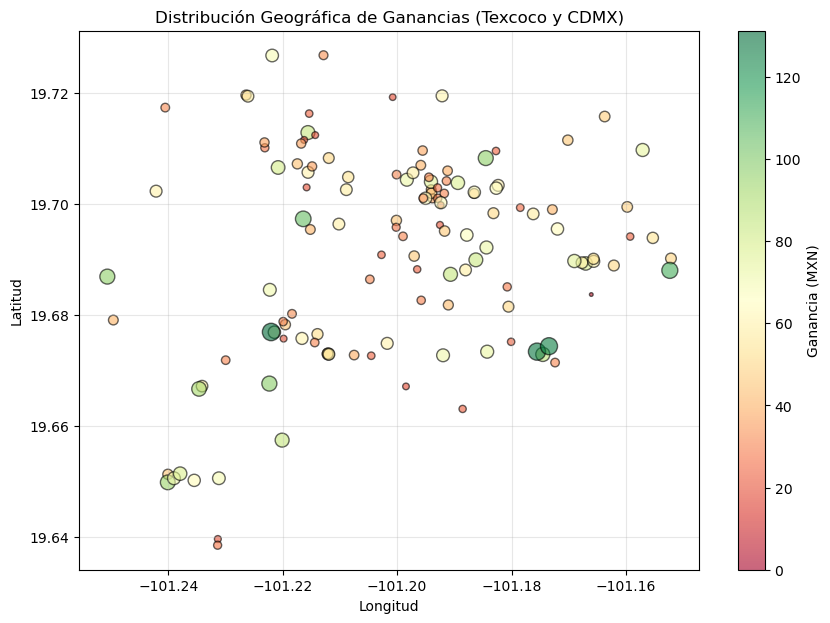

In [9]:
import pandas as pd
import json
import re
import matplotlib.pyplot as plt

# 1. Cargar el archivo JSON
try:
    with open('viajes_uber_detallados.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 2. Extraer Latitud, Longitud y Ganancias
    trips = []
    for item in data:
        meta = item.get('tripMetaData', {})
        if meta and meta.get('mapUrl'):
            # Buscamos latitud y longitud dentro del texto del link del mapa
            lat_match = re.search(r'lat%3A([\d\.-]+)', meta['mapUrl'])
            lng_match = re.search(r'lng%3A([\d\.-]+)', meta['mapUrl'])
            
            if lat_match and lng_match:
                # Limpiar el texto del dinero para convertirlo a número (ej: "MXN 130.50" -> 130.50)
                total_str = item.get('formattedTotal', '0')
                total_limpio = total_str.replace('MXN', '').replace('\xa0', '').replace(',', '.').strip()
                try:
                    total = float(total_limpio)
                except:
                    total = 0
                
                trips.append({
                    'lat': float(lat_match.group(1)),
                    'lng': float(lng_match.group(1)),
                    'total': total,
                    'address': meta.get('pickupAddress', 'Desconocida')
                })

    # 3. Crear el DataFrame df_map
    df_map = pd.DataFrame(trips)
    print(f"✅ ¡Éxito! Cargamos {len(df_map)} viajes.")

    # 4. Generar la Gráfica de Ganancias
    %matplotlib inline
    plt.figure(figsize=(10, 7))
    plt.scatter(df_map['lng'], df_map['lat'], 
                c=df_map['total'], cmap='RdYlGn', 
                s=df_map['total']*1.2, alpha=0.6, edgecolors='k')
    
    plt.colorbar(label='Ganancia (MXN)')
    plt.title('Distribución Geográfica de Ganancias (Texcoco y CDMX)')
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.grid(True, alpha=0.3)
    plt.show()

except FileNotFoundError:
    print("❌ Error: No encuentro el archivo 'viajes_uber_detallados.json'. Asegúrate de que esté en la misma carpeta que este Notebook.")

In [10]:
import folium
from folium.plugins import MarkerCluster, HeatMap
import pandas as pd
import json
import re

def extraer_duracion_forzada(item):
    # Convertimos todo el objeto a texto y quitamos espacios raros
    texto_sucio = str(item).replace('\\xa0', ' ').replace('&nbsp;', ' ')
    
    # 1. Buscador por patrón visual (lo que ves en la SS)
    # Busca un número que tenga "min" adelante, ignorando mayúsculas
    match = re.search(r'(\d+)\s*min', texto_sucio, re.IGNORECASE)
    if match:
        return f"{match.group(1)} min"
    
    # 2. Buscador en la etiqueta 'stats' pero limpiando símbolos
    meta = item.get('tripMetaData', {})
    stats = str(meta.get('stats', ''))
    # A veces viene como "6.71 km . 14" -> buscamos el 14
    numeros_en_stats = re.findall(r'\d+', stats)
    if len(numeros_en_stats) >= 2:
        # El segundo número suele ser el tiempo
        return f"{numeros_en_stats[-1]} min"
        
    return "No disp."

try:
    with open('viajes_uber_detallados.json', 'r', encoding='utf-8') as f:
        data_json = json.load(f)

    viajes_finales = []
    for item in data_json:
        if not item: continue
        meta = item.get('tripMetaData', {})
        
        if meta and meta.get('mapUrl'):
            lat_m = re.search(r'lat%3A([\d\.-]+)', meta['mapUrl'])
            lng_m = re.search(r'lng%3A([\d\.-]+)', meta['mapUrl'])
            
            if lat_m and lng_m:
                # Extraer distancia
                dist_m = re.search(r'([\d\.]+)\s*km', str(item).lower())
                distancia = f"{dist_m.group(1)} km" if dist_m else "N/D"

                # Extraer dinero
                total_str = item.get('formattedTotal', '0').replace('MXN', '').replace('\xa0', '').replace(',', '.').strip()
                
                viajes_finales.append({
                    'lat': float(lat_m.group(1)),
                    'lng': float(lng_m.group(1)),
                    'total': float(total_str) if total_str else 0,
                    'km': distancia,
                    'min': extraer_duracion_forzada(item), # NUEVA FUNCIÓN
                    'address': meta.get('pickupAddress', 'Ver mapa')
                })

    df_map = pd.DataFrame(viajes_finales)

    # Crear Mapa
    m = folium.Map(location=[df_map['lat'].mean(), df_map['lng'].mean()], zoom_start=11)
    HeatMap([[r['lat'], r['lng'], r['total']] for _, r in df_map.iterrows()], radius=15).add_to(m)
    mc = MarkerCluster(name="Detalle").add_to(m)

    for idx, row in df_map.iterrows():
        color = '#2ecc71' if row['total'] > 150 else '#f1c40f' if row['total'] > 80 else '#e74c3c'
        popup_html = f"""
        <div style="font-family: Arial; width: 180px; padding: 10px;">
            <div style="background:{color}; color:white; padding:5px; text-align:center; border-radius:5px;"><b>VIAJE #{idx+1}</b></div>
            <table style="width:100%; margin-top:10px;">
                <tr><td><b>💰 Pago:</b></td><td style="text-align:right;">${row['total']}</td></tr>
                <tr><td><b>📏 Distancia:</b></td><td style="text-align:right;">{row['km']}</td></tr>
                <tr><td><b>⏱️ Tiempo:</b></td><td style="text-align:right; font-weight:bold; color:blue;">{row['min']}</td></tr>
            </table>
        </div>
        """
        folium.CircleMarker([row['lat'], row['lng']], radius=8, color=color, fill=True, 
                            popup=folium.Popup(popup_html, max_width=250)).add_to(mc)

    display(m)
    print(f"✅ Análisis completado. Procesados {len(df_map)} viajes.")

except Exception as e:
    print(f"❌ Error: {e}")

✅ Análisis completado. Procesados 143 viajes.


📋 RESUMEN DE TUS MEJORES VIAJES:
     Viaje  Total  Minutos  Pesos_por_Minuto                            Origen
Viaje #108  77.65      5.0         15.530000 58341 Morelia, Michoacán de Oc...
 Viaje #18  49.50      4.0         12.375000 Avenida Ecuador, 58270 Morelia...
Viaje #105  70.73      6.0         11.788333 Calle San Cristóbal Ecatepec, ...
 Viaje #48 127.36     11.0         11.578182 Avenida Juan Pablo II, 58093 M...
 Viaje #77  50.98      5.0         10.196000 Segunda Privada de Ortega y Mo...


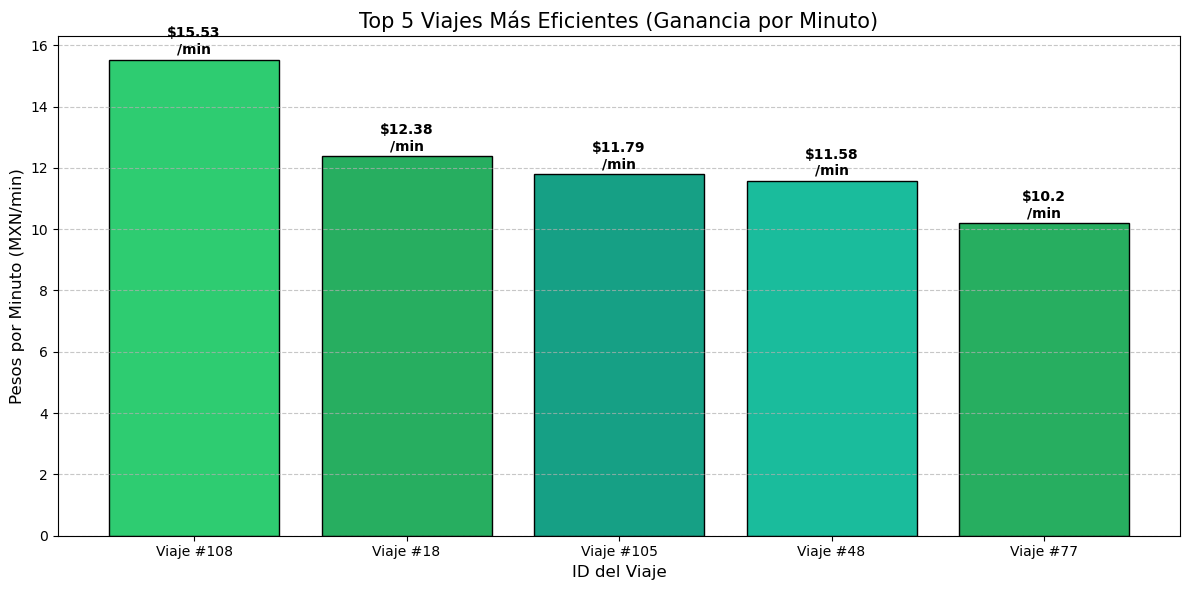

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import re

# 1. Procesar datos para obtener la rentabilidad
viajes_analisis = []
with open('viajes_uber_detallados.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

for item in data:
    meta = item.get('tripMetaData', {})
    if meta and meta.get('mapUrl'):
        # Extraer tiempo (usando la lógica que ya nos funcionó)
        texto = str(item).replace('\\xa0', ' ')
        match_t = re.search(r'(\d+)\s*min', texto, re.IGNORECASE)
        
        # Extraer dinero
        total_str = item.get('formattedTotal', '0').replace('MXN', '').replace('\xa0', '').replace(',', '.').strip()
        
        try:
            total = float(total_str)
            minutos = float(match_t.group(1)) if match_t else 0
            
            if minutos > 0:
                rentabilidad = total / minutos
                viajes_analisis.append({
                    'Viaje': f"Viaje #{len(viajes_analisis)+1}",
                    'Pesos_por_Minuto': rentabilidad,
                    'Total': total,
                    'Minutos': minutos,
                    'Origen': meta.get('pickupAddress', 'Ver mapa')[:30] + "..."
                })
        except:
            continue

# 2. Crear DataFrame y obtener el Top 5
df_top = pd.DataFrame(viajes_analisis)
df_top = df_top.sort_values(by='Pesos_por_Minuto', ascending=False).head(5)

# 3. Crear la Gráfica
plt.figure(figsize=(12, 6))
colores = ['#2ecc71', '#27ae60', '#16a085', '#1abc9c', '#27ae60']
bars = plt.bar(df_top['Viaje'], df_top['Pesos_por_Minuto'], color=colores, edgecolor='black')

# Añadir etiquetas de dinero sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'${round(yval, 2)}\n/min', 
             ha='center', va='bottom', fontweight='bold')

plt.title('Top 5 Viajes Más Eficientes (Ganancia por Minuto)', fontsize=15)
plt.ylabel('Pesos por Minuto (MXN/min)', fontsize=12)
plt.xlabel('ID del Viaje', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar tabla resumen debajo
print("📋 RESUMEN DE TUS MEJORES VIAJES:")
print(df_top[['Viaje', 'Total', 'Minutos', 'Pesos_por_Minuto', 'Origen']].to_string(index=False))

plt.tight_layout()
plt.show()